In [2]:
import os
os.chdir(os.path.expanduser("~/ransomware_xai_project"))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, precision_recall_curve, auc)
from sklearn.model_selection import cross_validate, StratifiedKFold
from scipy.stats import spearmanr

os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)

X_train = pd.read_csv("data/X_train_selected.csv", index_col=0)
X_test = pd.read_csv("data/X_test_selected.csv", index_col=0)
y_train = pd.read_csv("data/y_train.csv", index_col=0).squeeze()
y_test = pd.read_csv("data/y_test.csv", index_col=0).squeeze()
feature_names = X_train.columns.tolist()

from interpret.glassbox import ExplainableBoostingClassifier
models = {}
for fn, name in [('dt_model.joblib','Decision Tree'), ('ebm_model.joblib','EBM'),
                  ('rf_model.joblib','Random Forest'), ('xgb_model.joblib','XGBoost'),
                  ('lr_model.joblib','Logistic Regression')]:
    models[name] = joblib.load(f"models/{fn}")
    print(f"Loaded: {name}")

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print("Ready for final results")

Loaded: Decision Tree
Loaded: EBM
Loaded: Random Forest
Loaded: XGBoost
Loaded: Logistic Regression

Train: (46876, 20), Test: (11720, 20)
Ready for final results


In [3]:
print("=" * 80)
print("TABLE: COMPLETE MODEL PERFORMANCE — TEST SET")
print("=" * 80)

results = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    if name == 'EBM':
        y_proba = model.predict_proba(pd.DataFrame(X_test.values, columns=feature_names))[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
    pr_auc_val = auc(rec_c, prec_c)

    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall': round(recall_score(y_test, y_pred), 4),
        'F1-Score': round(f1_score(y_test, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4),
        'PR-AUC': round(pr_auc_val, 4),
        'FPR': round(fp / (fp + tn), 4),
        'FNR': round(fn / (fn + tp), 4),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    })

results_df = pd.DataFrame(results)
results_df.to_csv("results/tables/final_model_comparison.csv", index=False)

print(results_df[['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC','FPR','FNR']].to_string(index=False))
best = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\nBEST by F1: {best['Model']} ({best['F1-Score']})")
print("Saved: results/tables/final_model_comparison.csv")

TABLE: COMPLETE MODEL PERFORMANCE — TEST SET
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC    FPR    FNR
      Decision Tree    0.9997     0.9998  0.9997    0.9997   0.9997 0.0002 0.0003
                EBM    1.0000     1.0000  1.0000    1.0000   1.0000 0.0000 0.0000
      Random Forest    1.0000     1.0000  1.0000    1.0000   1.0000 0.0000 0.0000
            XGBoost    0.9999     0.9998  1.0000    0.9999   1.0000 0.0002 0.0000
Logistic Regression    0.9985     0.9985  0.9985    0.9985   1.0000 0.0015 0.0015

BEST by F1: EBM (1.0)
Saved: results/tables/final_model_comparison.csv


In [4]:
print("=" * 60)
print("TABLE: 5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results = []

for name, model in models.items():
    print(f"  CV: {name}...", end=" ")
    if name == 'EBM':
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(pd.DataFrame(X_test.values, columns=feature_names))[:, 1]
        cv_results.append({
            'Model': name,
            'Accuracy': f"{accuracy_score(y_test, y_pred):.4f}",
            'Precision': f"{precision_score(y_test, y_pred):.4f}",
            'Recall': f"{recall_score(y_test, y_pred):.4f}",
            'F1-Score': f"{f1_score(y_test, y_pred):.4f}",
            'ROC-AUC': f"{roc_auc_score(y_test, y_proba):.4f}",
        })
        print("done (test set)")
    else:
        scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
        cv_results.append({
            'Model': name,
            'Accuracy': f"{scores['test_accuracy'].mean():.4f} ±{scores['test_accuracy'].std():.4f}",
            'Precision': f"{scores['test_precision'].mean():.4f} ±{scores['test_precision'].std():.4f}",
            'Recall': f"{scores['test_recall'].mean():.4f} ±{scores['test_recall'].std():.4f}",
            'F1-Score': f"{scores['test_f1'].mean():.4f} ±{scores['test_f1'].std():.4f}",
            'ROC-AUC': f"{scores['test_roc_auc'].mean():.4f} ±{scores['test_roc_auc'].std():.4f}",
        })
        print("done")

cv_df = pd.DataFrame(cv_results)
cv_df.to_csv("results/tables/cross_validation_results.csv", index=False)
print("\n" + cv_df.to_string(index=False))
print("\nSaved: results/tables/cross_validation_results.csv")

TABLE: 5-FOLD CROSS-VALIDATION RESULTS
  CV: Decision Tree... done
  CV: EBM... done (test set)
  CV: Random Forest... done
  CV: XGBoost... done
  CV: Logistic Regression... done

              Model       Accuracy      Precision         Recall       F1-Score        ROC-AUC
      Decision Tree 0.9998 ±0.0001 0.9998 ±0.0001 0.9997 ±0.0002 0.9998 ±0.0001 0.9998 ±0.0001
                EBM         1.0000         1.0000         1.0000         1.0000         1.0000
      Random Forest 0.9999 ±0.0001 0.9998 ±0.0002 1.0000 ±0.0000 0.9999 ±0.0001 1.0000 ±0.0000
            XGBoost 0.9999 ±0.0001 0.9999 ±0.0001 1.0000 ±0.0001 0.9999 ±0.0001 1.0000 ±0.0000
Logistic Regression 0.9990 ±0.0004 0.9993 ±0.0004 0.9986 ±0.0005 0.9990 ±0.0004 1.0000 ±0.0000

Saved: results/tables/cross_validation_results.csv


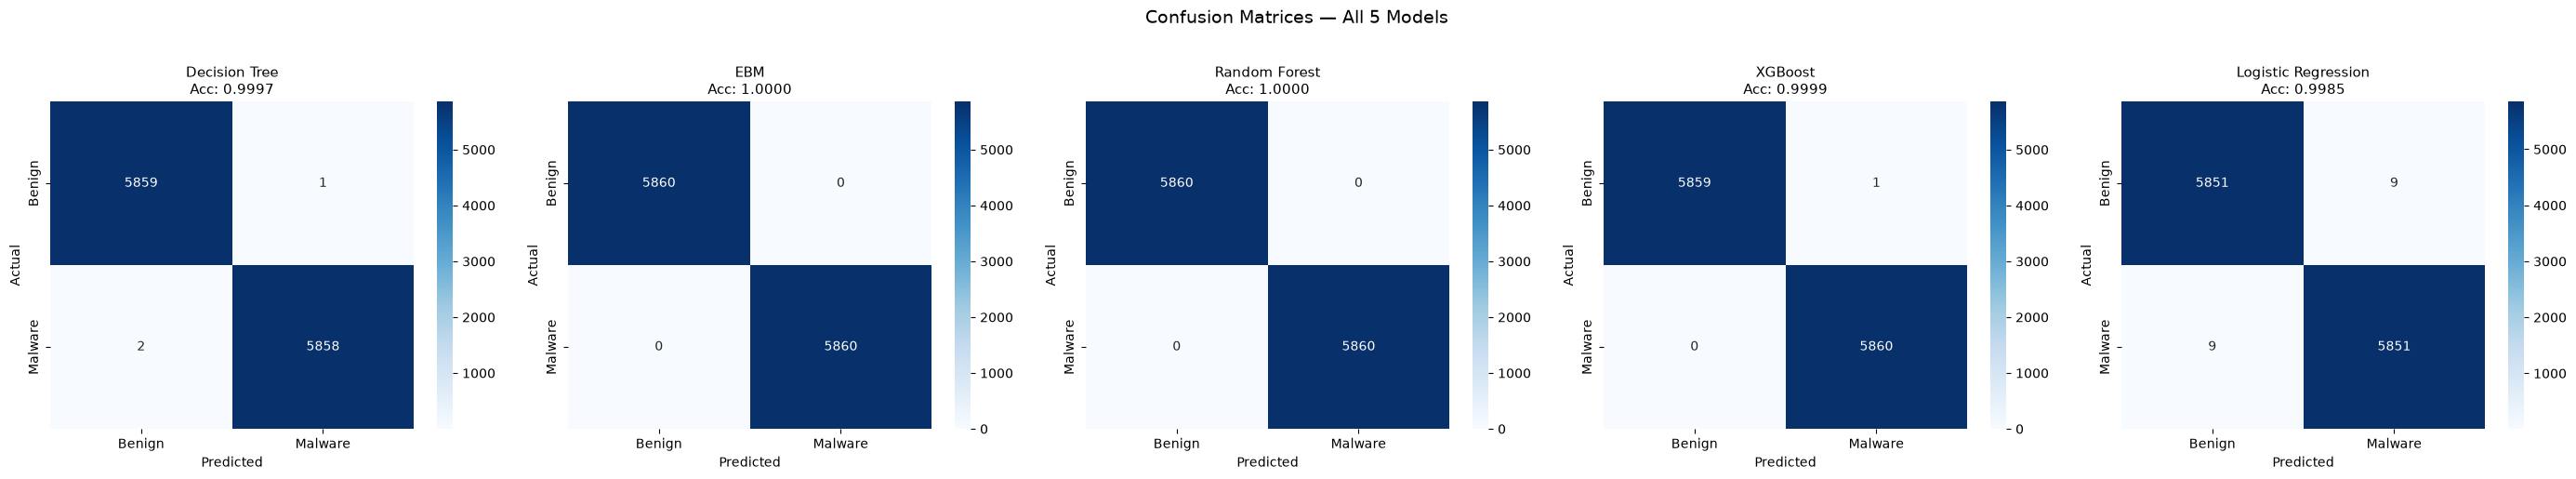

Saved: results/figures/confusion_matrices_all.png


In [5]:
fig, axes = plt.subplots(1, 5, figsize=(28, 5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
    ax.set_title(f"{name}\nAcc: {accuracy_score(y_test, y_pred):.4f}", fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle("Confusion Matrices — All 5 Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/figures/confusion_matrices_all.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/figures/confusion_matrices_all.png")

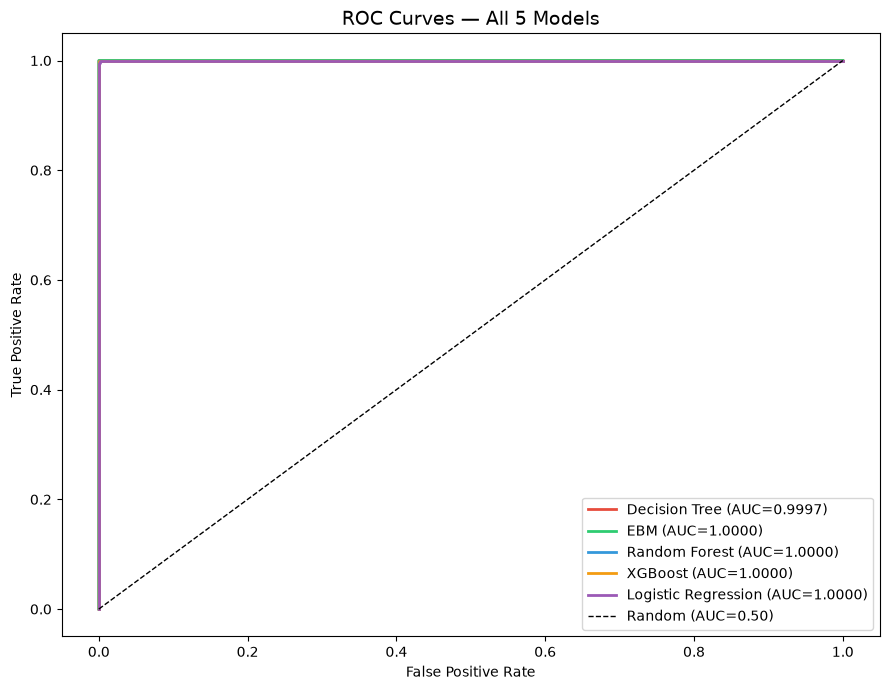

Saved: results/figures/roc_curves_all.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

for (name, model), color in zip(models.items(), colors):
    if name == 'EBM':
        y_proba = model.predict_proba(pd.DataFrame(X_test.values, columns=feature_names))[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]
    fpr_vals, tpr_vals, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax.plot(fpr_vals, tpr_vals, color=color, lw=2, label=f"{name} (AUC={auc_val:.4f})")

ax.plot([0,1], [0,1], 'k--', lw=1, label='Random (AUC=0.50)')
ax.set_title('ROC Curves — All 5 Models', fontsize=14)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
plt.tight_layout()
plt.savefig("results/figures/roc_curves_all.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/figures/roc_curves_all.png")

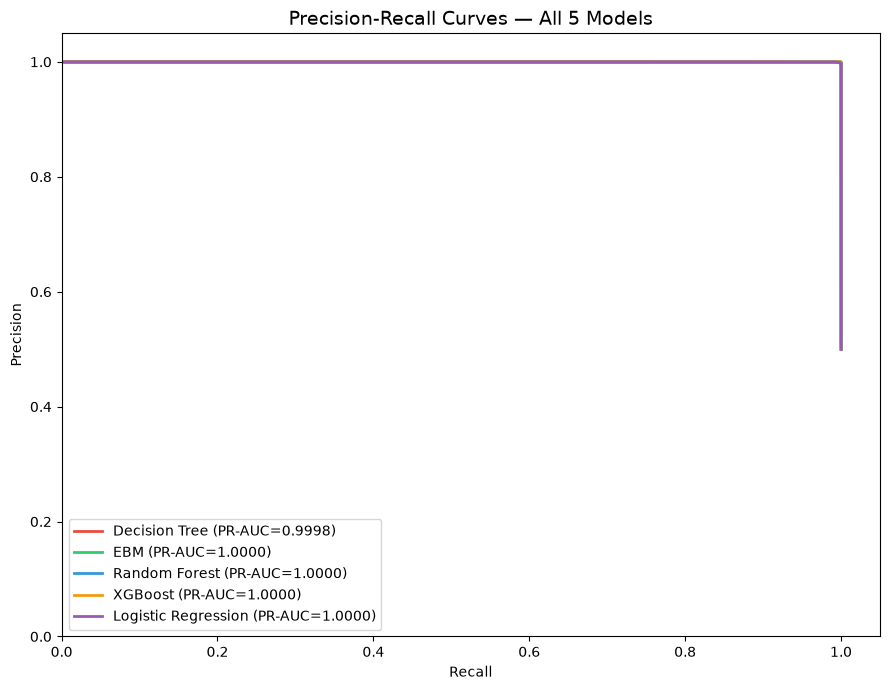

Saved: results/figures/precision_recall_curves.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

for (name, model), color in zip(models.items(), colors):
    if name == 'EBM':
        y_proba = model.predict_proba(pd.DataFrame(X_test.values, columns=feature_names))[:, 1]
    else:
        y_proba = model.predict_proba(X_test)[:, 1]
    prec_c, rec_c, _ = precision_recall_curve(y_test, y_proba)
    pr_auc_val = auc(rec_c, prec_c)
    ax.plot(rec_c, prec_c, color=color, lw=2, label=f"{name} (PR-AUC={pr_auc_val:.4f})")

ax.set_title('Precision-Recall Curves — All 5 Models', fontsize=14)
ax.legend(loc='lower left', fontsize=10)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_xlim([0, 1.05])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig("results/figures/precision_recall_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/figures/precision_recall_curves.png")

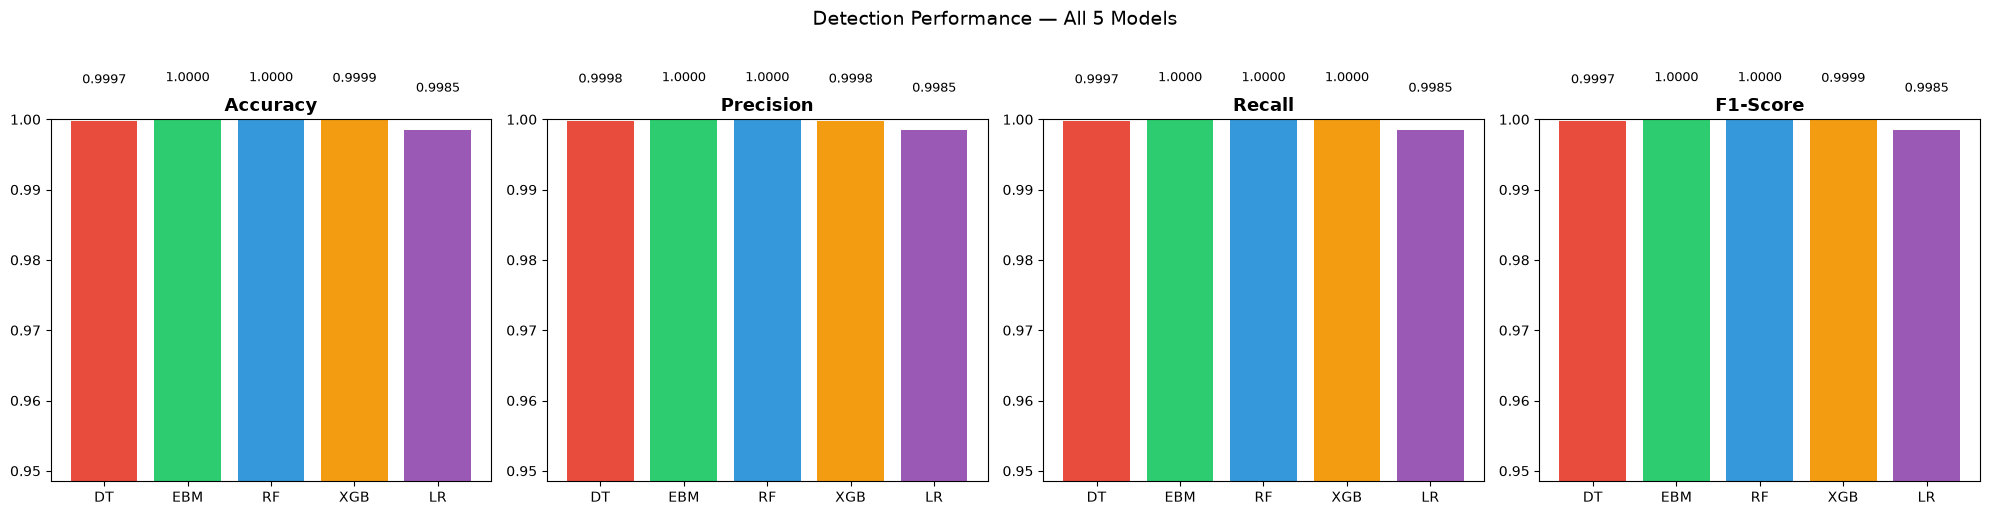

Saved: results/figures/performance_bars.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#e74c3c', '#2ecc71', '#3498db', '#f39c12', '#9b59b6']

for ax, metric in zip(axes, metrics):
    values = results_df[metric].values
    bars = ax.bar(range(len(models)), values, color=colors)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(['DT', 'EBM', 'RF', 'XGB', 'LR'], fontsize=10)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(min(values) - 0.05, 1.0)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle("Detection Performance — All 5 Models", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("results/figures/performance_bars.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/figures/performance_bars.png")

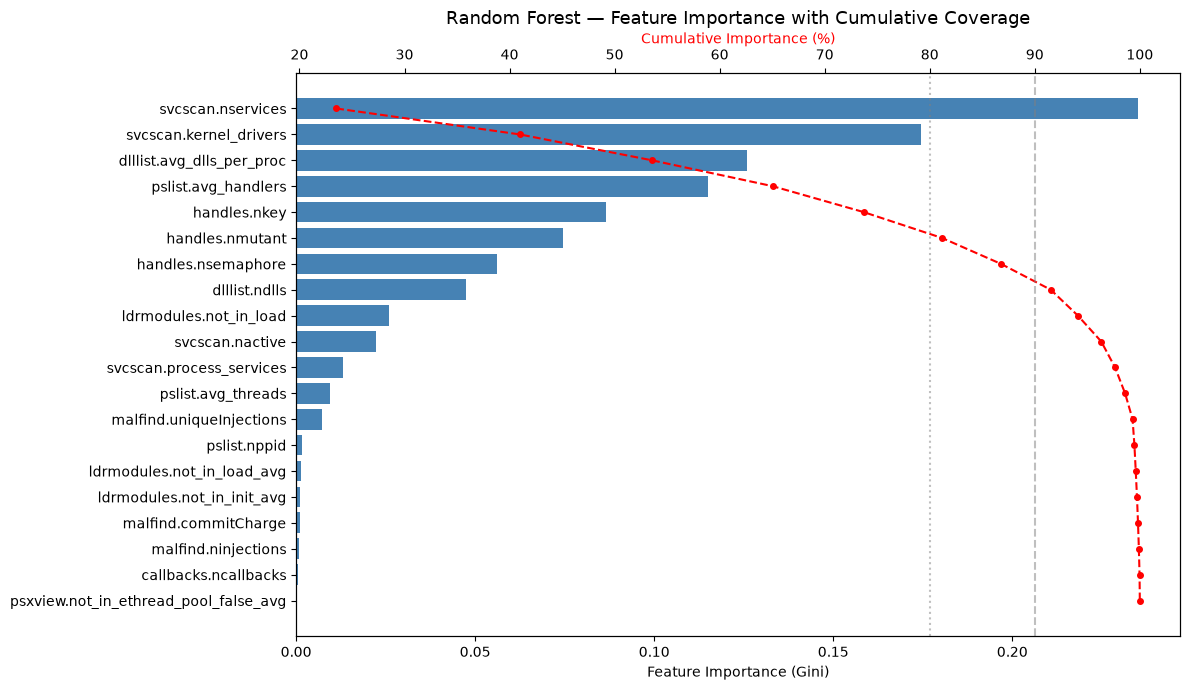

Top 10 features:
                  feature  importance  cumulative
        svcscan.nservices    0.235075   23.507475
   svcscan.kernel_drivers    0.174509   40.958329
dlllist.avg_dlls_per_proc    0.125941   53.552450
      pslist.avg_handlers    0.114946   65.047036
             handles.nkey    0.086602   73.707195
          handles.nmutant    0.074644   81.171575
       handles.nsemaphore    0.056067   86.778255
            dlllist.ndlls    0.047462   91.524414
   ldrmodules.not_in_load    0.025820   94.106452
          svcscan.nactive    0.022248   96.331234

Saved: results/figures/feature_importance_RF.png


In [9]:
rf_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': models['Random Forest'].feature_importances_
}).sort_values('importance', ascending=False)
rf_imp['cumulative'] = rf_imp['importance'].cumsum() / rf_imp['importance'].sum() * 100

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.barh(rf_imp['feature'][::-1], rf_imp['importance'][::-1], color='steelblue')
ax1.set_xlabel('Feature Importance (Gini)')
ax1.set_title('Random Forest — Feature Importance with Cumulative Coverage', fontsize=13)

ax2 = ax1.twiny()
ax2.plot(rf_imp['cumulative'].values, range(len(rf_imp)-1, -1, -1), 'r--o', markersize=4)
ax2.set_xlabel('Cumulative Importance (%)', color='red')
ax2.axvline(x=80, color='gray', linestyle=':', alpha=0.5, label='80%')
ax2.axvline(x=90, color='gray', linestyle='--', alpha=0.5, label='90%')

plt.tight_layout()
plt.savefig("results/figures/feature_importance_RF.png", dpi=300, bbox_inches='tight')
plt.show()

rf_imp.to_csv("results/tables/feature_importance_RF.csv", index=False)
print("Top 10 features:")
print(rf_imp.head(10).to_string(index=False))
print("\nSaved: results/figures/feature_importance_RF.png")

In [10]:
print("=" * 80)
print("INTEGRATED DUAL-CRITERION COMPARISON")
print("Detection + Explainability")
print("=" * 80)

try:
    cons_df = pd.read_csv("results/tables/shap_lime_consistency.csv")
except:
    cons_df = pd.DataFrame({
        'Model': list(models.keys()),
        'Spearman_rho': [0.0]*5,
        'Top5_overlap': ['N/A']*5,
        'Agreement': ['N/A']*5
    })

dual = results_df[['Model','Accuracy','F1-Score','ROC-AUC','FPR']].copy()
dual = dual.merge(cons_df[['Model','Spearman_rho','Top5_overlap','Agreement']], on='Model', how='left')
dual['Overall'] = (dual['F1-Score'] * 0.5) + (dual['Spearman_rho'].fillna(0) * 0.5)
dual['Rank'] = dual['Overall'].rank(ascending=False).astype(int)
dual = dual.sort_values('Rank')

dual.to_csv("results/tables/dual_criterion_comparison.csv", index=False)
print(dual.to_string(index=False))

best = dual.iloc[0]
print(f"\nBEST OVERALL: {best['Model']}")
print(f"  F1={best['F1-Score']}, SHAP-LIME rho={best['Spearman_rho']}")
print("Saved: results/tables/dual_criterion_comparison.csv")

INTEGRATED DUAL-CRITERION COMPARISON
Detection + Explainability
              Model  Accuracy  F1-Score  ROC-AUC    FPR  Spearman_rho Top5_overlap Agreement  Overall  Rank
Logistic Regression    0.9985    0.9985   1.0000 0.0015         0.961   5/5 (100%) Excellent  0.97975     1
            XGBoost    0.9999    0.9999   1.0000 0.0002         0.870    3/5 (60%)    Strong  0.93495     2
      Decision Tree    0.9997    0.9997   0.9997 0.0002         0.861    4/5 (80%)    Strong  0.93035     3
                EBM    1.0000    1.0000   1.0000 0.0000         0.618    3/5 (60%)  Moderate  0.80900     4
      Random Forest    1.0000    1.0000   1.0000 0.0000         0.598    4/5 (80%)  Moderate  0.79900     5

BEST OVERALL: Logistic Regression
  F1=0.9985, SHAP-LIME rho=0.961
Saved: results/tables/dual_criterion_comparison.csv


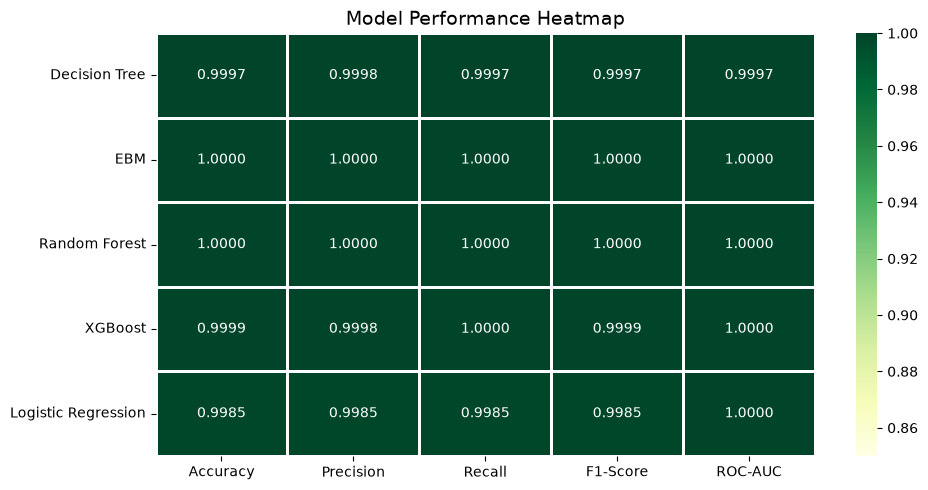

Saved: results/figures/performance_heatmap.png


In [11]:
heat_data = results_df[['Model','Accuracy','Precision','Recall','F1-Score','ROC-AUC']].set_index('Model')

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlGn', ax=ax,
            linewidths=1, linecolor='white', vmin=0.85, vmax=1.0)
ax.set_title('Model Performance Heatmap', fontsize=14)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig("results/figures/performance_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: results/figures/performance_heatmap.png")

['Model', 'Accuracy', 'F1-Score', 'ROC-AUC', 'FPR', 'Spearman_rho', 'Top5_overlap', 'Agreement', 'Overall', 'Rank']


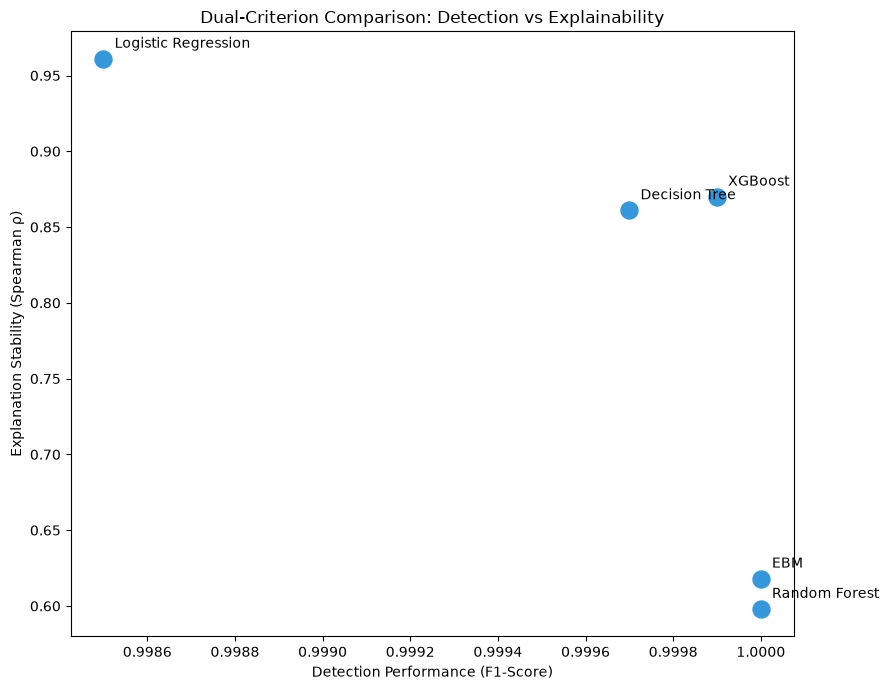

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

dual = pd.read_csv("results/tables/dual_criterion_comparison.csv")
print(dual.columns.tolist())  # confirm exact column names first

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(dual['F1-Score'], dual['Spearman_rho'], s=150, color='#3498db')

for i, row in dual.iterrows():
    ax.annotate(row['Model'], (row['F1-Score'], row['Spearman_rho']),
                textcoords="offset points", xytext=(8, 8), fontsize=10)

ax.set_xlabel('Detection Performance (F1-Score)')
ax.set_ylabel('Explanation Stability (Spearman ρ)')
ax.set_title('Dual-Criterion Comparison: Detection vs Explainability')
plt.tight_layout()
plt.savefig("results/figures/dual_criterion_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

In [13]:
print("=" * 60)
print("ALL PROJECT FILES — FINAL OUTPUT")
print("=" * 60)

total_files = 0
for folder in ['models', 'data', 'results/tables', 'results/figures', 'results/shap_plots']:
    if os.path.exists(folder):
        files = sorted([f for f in os.listdir(folder) if not f.startswith('.')])
        if files:
            print(f"\n{folder}/")
            for f in files:
                size = os.path.getsize(f"{folder}/{f}") // 1024
                print(f"  {f} ({size}KB)")
                total_files += 1

print(f"\n{'='*60}")
print(f"TOTAL: {total_files} files generated")
print(f"{'='*60}")

ALL PROJECT FILES — FINAL OUTPUT

models/
  dt_model.joblib (4KB)
  ebm_model.joblib (4216KB)
  lr_model.joblib (1KB)
  rf_model.joblib (538KB)
  xgb_model.joblib (198KB)

data/
  MalMem2022.csv (19175KB)
  X_test_selected.csv (4614KB)
  X_test_unscaled.csv (1414KB)
  X_train_selected.csv (18453KB)
  X_train_unscaled.csv (5651KB)
  y_test.csv (89KB)
  y_train.csv (357KB)

results/tables/
  cross_validation_results.csv (0KB)
  dual_criterion_comparison.csv (0KB)
  feature_importance_RF.csv (1KB)
  final_model_comparison.csv (0KB)
  lime_rankings_all_models.csv (2KB)
  model_comparison.csv (0KB)
  shap_lime_consistency.csv (0KB)
  shap_rankings_all_models.csv (2KB)

results/figures/
  category_distribution.png (71KB)
  confusion_matrices_all.png (185KB)
  dual_criterion_comparison.png (134KB)
  feature_importance_RF.png (265KB)
  lime_explanation_RF.png (126KB)
  lime_explanation_example.html (1203KB)
  mutual_information_scores.png (191KB)
  performance_bars.png (182KB)
  performance_he